<a href="https://colab.research.google.com/github/asna-m-nassar/ml-lab-exp-1/blob/main/Experiment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from sklearn.datasets import fetch_california_housing

In [5]:
from sklearn.metrics import mean_squared_error,r2_score

In [6]:
housing = fetch_california_housing(as_frame=True)

In [7]:
df = housing.frame

In [8]:
X = df[['AveRooms']].values

In [9]:
y =df['MedHouseVal'].values.reshape(-1,1)

In [10]:
X_b = np.c_[np.ones((len(X),1)),X]

In [11]:
theta_normal = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [12]:
y_pred_normal = X_b @ theta_normal

In [13]:
print("----Normal Equation----")
print("Intercept :",theta_normal[0][0])
print("Slope :",theta_normal[1][0])
print("MSE :",mean_squared_error(y,y_pred_normal))
print("R2 Score :",r2_score(y,y_pred_normal))

----Normal Equation----
Intercept : 1.6838115086404832
Slope : 0.0708687932804052
MSE : 1.3008070902505424
R2 Score : 0.023088282755354017


In [14]:
def compute_cost(X,y,theta):
    m=len(y)
    predictions=X@theta
    cost=(1/(2*m)) * np.sum((predictions-y)*2)
    return cost

In [15]:
def gradient_descent(X,y,theta,learning_rate,iterations):
  m=len(y)
  cost_history=[]
  for i in range(iterations):
   gradients=(1/m)*X.T@(X@theta-y)
   theta=theta-learning_rate*gradients
   cost_history.append(compute_cost(X,y,theta))
  return theta,cost_history

In [16]:
theta=np.zeros((2,1))
learning_rate=0.001
iterations=1000
theta_gd,cost_history=gradient_descent(X_b,y,theta,learning_rate,iterations)
y_pred_gd=X_b@theta_gd


In [17]:
print("----Gradient Descent----")
print("Intercept :",theta_gd[0][0])
print("Slope :",theta_gd[1][0])
print("MSE :",mean_squared_error(y,y_pred_gd))
print("R2 Score :",r2_score(y,y_pred_gd))

----Gradient Descent----
Intercept : 0.30209997653075465
Slope : 0.2826073529823789
MSE : 1.6291507228490774
R2 Score : -0.22349919695034104


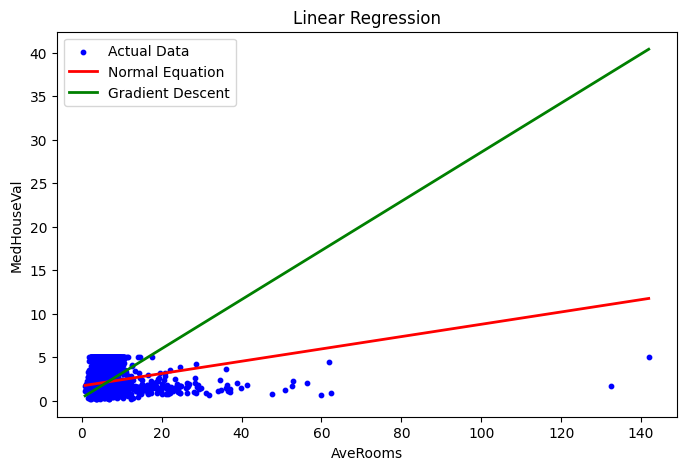

In [18]:
import numpy as np
sort_index=np.argsort(X.flatten())
plt.figure(figsize=(8,5))
plt.scatter(X,y,s=10,color='blue',label='Actual Data')
plt.plot(X[sort_index],y_pred_normal[sort_index],color='red',linewidth=2,label='Normal Equation')
plt.plot(X[sort_index],y_pred_gd[sort_index],color='green',linewidth=2,label='Gradient Descent')
plt.xlabel('AveRooms')
plt.ylabel('MedHouseVal')
plt.title('Linear Regression')
plt.legend()
plt.show()

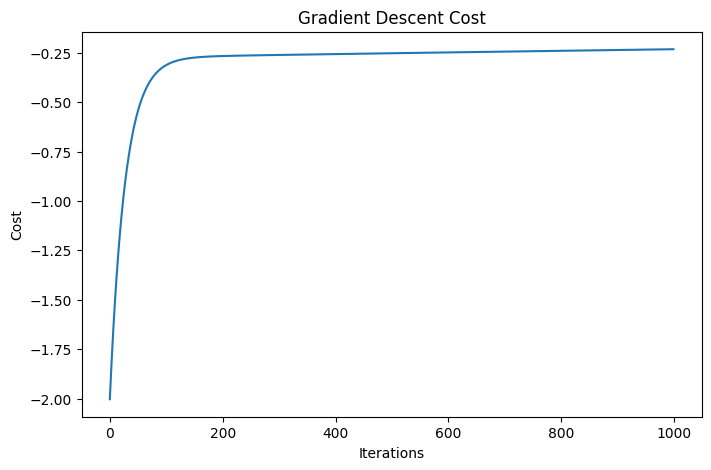

In [19]:
plt.figure(figsize=(8,5))
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Gradient Descent Cost")
plt.show()